<a href="https://colab.research.google.com/github/pondpatipatpankaew/GE337/blob/main/Lab/Lab_3_%E0%B8%9B%E0%B8%8F%E0%B8%B4%E0%B8%9E%E0%B8%B1%E0%B8%92%E0%B8%99%E0%B9%8C_6606520168.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Install Libraries**

In [1]:
!pip install geopandas rasterio folium -q

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
import folium

## **Connect Google Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Set Data Path**

In [4]:
path = "/content/drive/MyDrive/Labdata/Data"

print("Files in folder:")

for f in os.listdir(path):
    print(f)

Files in folder:
lopdem.tif
FarmPoint.shp.xml
FarmPoint.sbx
FarmPoint.shx
FarmPoint.shp
ForestPoint.shp.xml
ForestPoint.cpg
ForestPoint.prj
ForestPoint.shx
ForestPoint.shp
ForestPoint.sbx
ForestPoint.sbn
ForestPoint.dbf
lop2025.tif
Lop2022.tif
Lopburi.shx
Lopburi.shp.DESKTOP-EGIT7KP.25580.22168.sr.lock
Lopburi.dbf
Lopburi.cpg
Lopburi.shp
Lopburi.shp.DESKTOP-EGIT7KP.17116.22168.sr.lock
Lopburi.prj
Lopburi.sbx
Lopburi.sbn
Lopburi.shp.xml


## **Load & Prepare Data**

In [5]:
#Load Raster Data
img_2022 = rasterio.open(path + "/Lop2022.tif")
img_2025 = rasterio.open(path + "/lop2025.tif")
dem = rasterio.open(path + "/lopdem.tif")

In [6]:
print("\n--- Raster Information ---")

print("CRS:", img_2022.crs)
print("Resolution:", img_2022.res)
print("Number of Bands:", img_2022.count)
print("Metadata:", img_2022.meta)


--- Raster Information ---
CRS: EPSG:4326
Resolution: (0.0006180181576575864, 0.0005961566358528606)
Number of Bands: 12
Metadata: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 2481, 'height': 2501, 'count': 12, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0006180181576575864, 0.0, 100.2306057457928,
       0.0, -0.0005961566358528606, 15.961958759260469)}


In [7]:
#Load Vector Data
farm = gpd.read_file(path + "/FarmPoint.shp")
forest = gpd.read_file(path + "/ForestPoint.shp")
boundary = gpd.read_file(path + "/Lopburi.shp")

In [8]:
#Fix Coordinate System
farm = farm.set_crs("EPSG:32647")

farm = farm.to_crs("EPSG:4326")
forest = forest.to_crs("EPSG:4326")

print("\n--- CRS Check ---")

print("Boundary:", boundary.crs)
print("Farm:", farm.crs)
print("Forest:", forest.crs)


--- CRS Check ---
Boundary: EPSG:4326
Farm: EPSG:4326
Forest: EPSG:4326


In [9]:
#Clip Points inside Boundary
farm_clip = gpd.clip(farm, boundary)
forest_clip = gpd.clip(forest, boundary)

print("\n--- Point Count ---")

print("Farm before:", len(farm))
print("Farm after:", len(farm_clip))

print("Forest before:", len(forest))
print("Forest after:", len(forest_clip))


--- Point Count ---
Farm before: 17
Farm after: 17
Forest before: 12
Forest after: 10


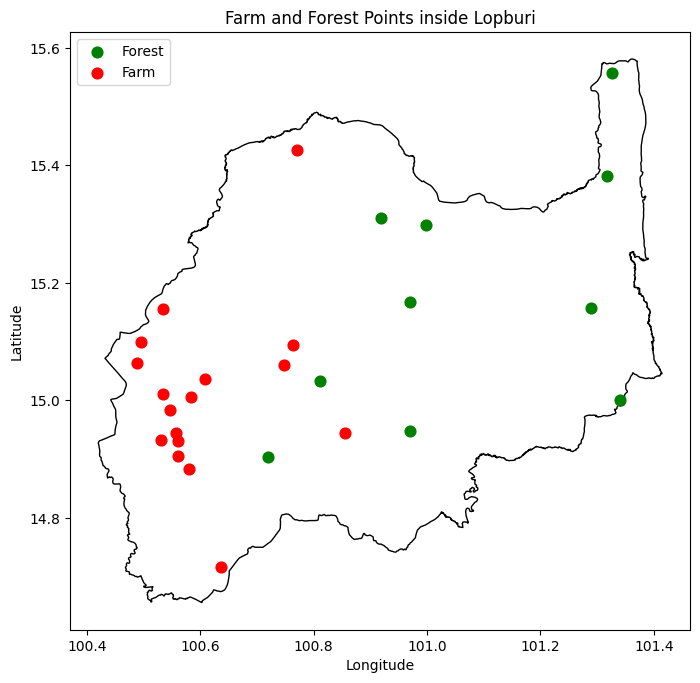

In [10]:
fig, ax = plt.subplots(figsize=(8,8))

boundary.plot(ax=ax, facecolor="none", edgecolor="black")

forest_clip.plot(ax=ax, color="green", markersize=60, label="Forest")

farm_clip.plot(ax=ax, color="red", markersize=60, label="Farm")

plt.legend()
plt.title("Farm and Forest Points inside Lopburi")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

## **NDVI Calculation**

In [11]:
#Clip Raster ตาม Boundary
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling

boundary_raster = boundary.to_crs(img_2022.crs)

clipped_2022, transform_2022 = mask(
    img_2022,
    boundary_raster.geometry,
    crop=True
)

clipped_2025, transform_2025 = mask(
    img_2025,
    boundary_raster.geometry,
    crop=True
)

In [12]:
red_2022 = clipped_2022[3].astype(float)
nir_2022 = clipped_2022[7].astype(float)

red_2025 = clipped_2025[3].astype(float)
nir_2025 = clipped_2025[7].astype(float)

In [13]:
ndvi_2022 = (nir_2022 - red_2022) / (nir_2022 + red_2022)
ndvi_2025 = (nir_2025 - red_2025) / (nir_2025 + red_2025)

ndvi_2022 = np.where((nir_2022 + red_2022)==0,0,ndvi_2022)
ndvi_2025 = np.where((nir_2025 + red_2025)==0,0,ndvi_2025)

/tmp/ipykernel_562/1181373554.py:1: RuntimeWarning: invalid value encountered in divide
  ndvi_2022 = (nir_2022 - red_2022) / (nir_2022 + red_2022)
/tmp/ipykernel_562/1181373554.py:2: RuntimeWarning: invalid value encountered in divide
  ndvi_2025 = (nir_2025 - red_2025) / (nir_2025 + red_2025)


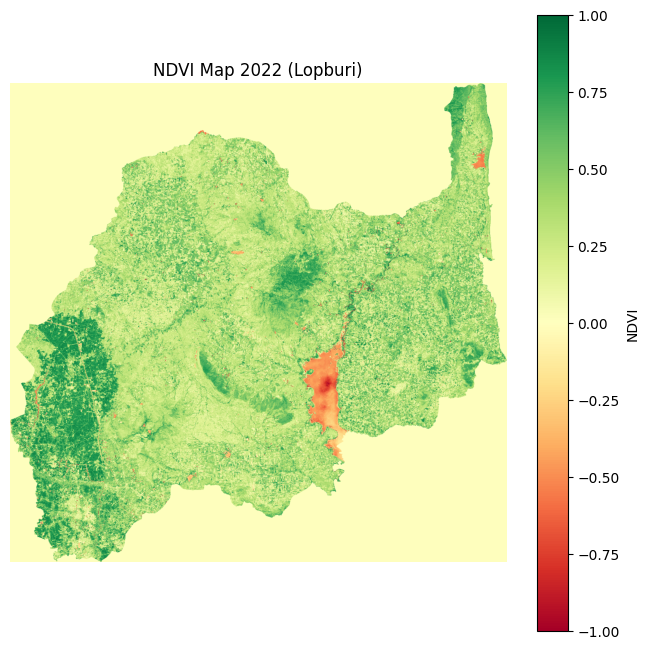

In [14]:
fig, ax = plt.subplots(figsize=(8,8))

img = ax.imshow(ndvi_2022, cmap="RdYlGn", vmin=-1, vmax=1)

plt.colorbar(img, ax=ax, label="NDVI")

plt.title("NDVI Map 2022 (Lopburi)")

plt.axis("off")

plt.show()

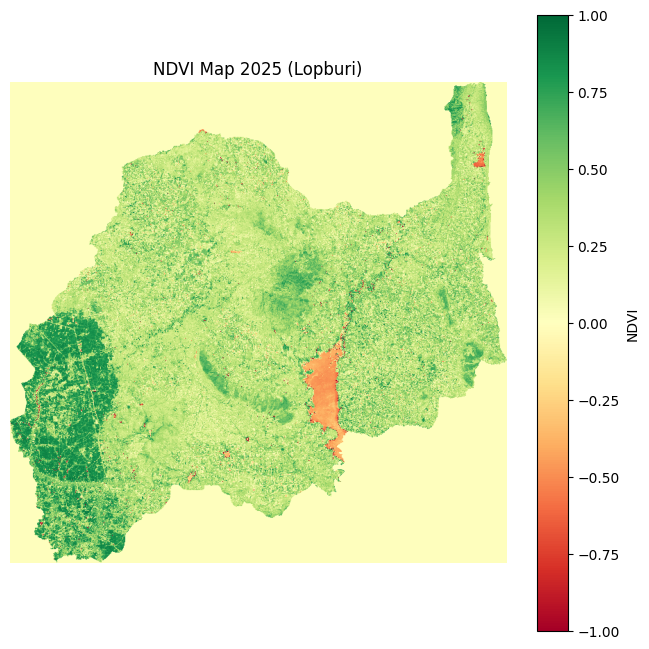

In [15]:
fig, ax = plt.subplots(figsize=(8,8))

img = ax.imshow(ndvi_2025, cmap="RdYlGn", vmin=-1, vmax=1)

plt.colorbar(img, ax=ax, label="NDVI")

plt.title("NDVI Map 2025 (Lopburi)")

plt.axis("off")

plt.show()

## **Calculate NDVI Difference**

In [17]:
#Resample ให้ขนาดตรงกัน
ndvi_2025_resampled = np.empty_like(ndvi_2022)

reproject(
    source=ndvi_2025,
    destination=ndvi_2025_resampled,
    src_transform=transform_2025,
    src_crs=img_2025.crs,
    dst_transform=transform_2022,
    dst_crs=img_2022.crs,
    resampling=Resampling.bilinear
)

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 Affine(0.0006180181576575864, 0.0, 100.41971930203603,
        0.0, -0.0005961566358528606, 15.581610825586344))

In [18]:
ndvi_diff = ndvi_2025_resampled - ndvi_2022

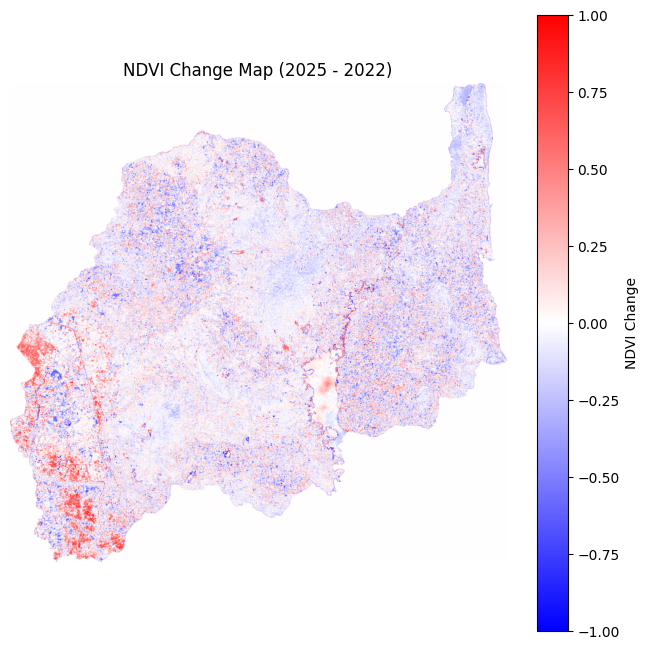

In [19]:
fig, ax = plt.subplots(figsize=(8,8))

img = ax.imshow(ndvi_diff, cmap="bwr", vmin=-1, vmax=1)

plt.colorbar(img, ax=ax, label="NDVI Change")

plt.title("NDVI Change Map (2025 - 2022)")

plt.axis("off")

plt.show()

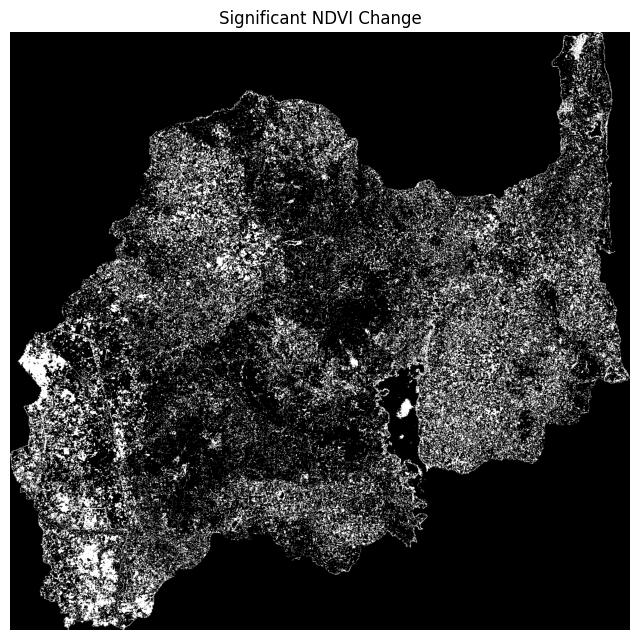

In [21]:
#Threshold Detection
threshold = 0.2

change_mask = np.abs(ndvi_diff) > threshold

fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(change_mask, cmap="gray")

plt.title("Significant NDVI Change")

plt.axis("off")

plt.show()

In [22]:
dem_clip, dem_transform = mask(
    dem,
    boundary_raster.geometry,
    crop=True
)

dem_data = dem_clip[0]

In [23]:
dem_resampled = np.empty_like(ndvi_2022)

reproject(
    source=dem_data,
    destination=dem_resampled,
    src_transform=dem_transform,
    src_crs=dem.crs,
    dst_transform=transform_2022,
    dst_crs=img_2022.crs,
    resampling=Resampling.bilinear
)

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 Affine(0.0006180181576575864, 0.0, 100.41971930203603,
        0.0, -0.0005961566358528606, 15.581610825586344))

In [24]:
ndvi_flat = ndvi_2022.flatten()
dem_flat = dem_resampled.flatten()

mask_valid = (~np.isnan(ndvi_flat)) & (~np.isnan(dem_flat))

ndvi_flat = ndvi_flat[mask_valid]
dem_flat = dem_flat[mask_valid]

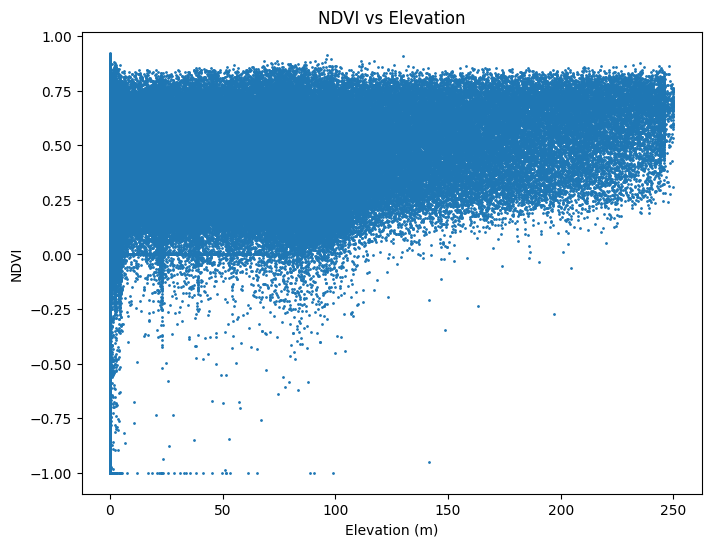

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(dem_flat, ndvi_flat, s=1)

plt.xlabel("Elevation (m)")
plt.ylabel("NDVI")

plt.title("NDVI vs Elevation")

plt.show()

## **Summary**

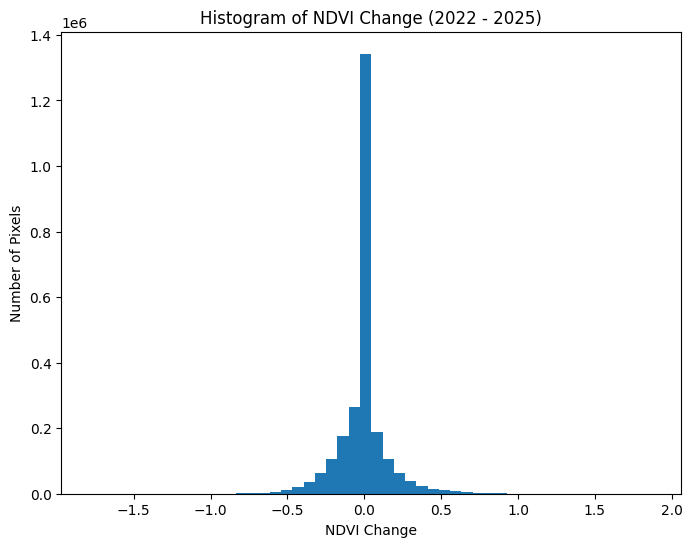

In [26]:
plt.figure(figsize=(8,6))

plt.hist(ndvi_diff.flatten(), bins=50)

plt.xlabel("NDVI Change")
plt.ylabel("Number of Pixels")

plt.title("Histogram of NDVI Change (2022 - 2025)")

plt.show()

In [28]:
#NDVI Change Statistics
print("Minimum NDVI Change:", np.nanmin(ndvi_diff))
print("Maximum NDVI Change:", np.nanmax(ndvi_diff))
print("Mean NDVI Change:", np.nanmean(ndvi_diff))

Minimum NDVI Change: -1.787642343907962
Maximum NDVI Change: 1.8790407590393372
Mean NDVI Change: -0.007821128771062637


In [30]:
#Area of Change
increase = ndvi_diff > 0.2
decrease = ndvi_diff < -0.2

print("Pixels NDVI Increase:", np.sum(increase))
print("Pixels NDVI Decrease:", np.sum(decrease))

Pixels NDVI Increase: 164136
Pixels NDVI Decrease: 207640


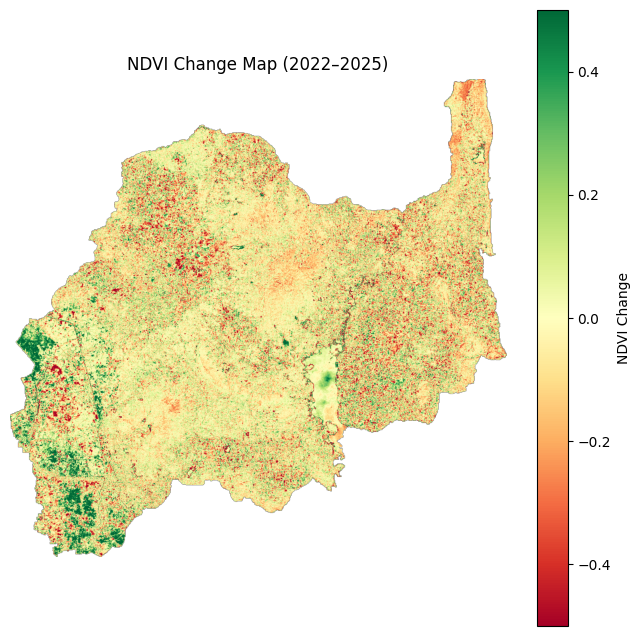

In [34]:
ndvi_masked = np.ma.masked_where(ndvi_diff == 0, ndvi_diff)

plt.figure(figsize=(8,8))

img = plt.imshow(
    ndvi_masked,
    cmap="RdYlGn",
    vmin=-0.5,
    vmax=0.5
)

plt.colorbar(img, label="NDVI Change")

plt.title("NDVI Change Map (2022–2025)")

plt.axis("off")

plt.show()

In [35]:
print("===== NDVI Statistics =====")

print("NDVI 2022")
print("Min:", np.nanmin(ndvi_2022))
print("Max:", np.nanmax(ndvi_2022))
print("Mean:", np.nanmean(ndvi_2022))
print("Std:", np.nanstd(ndvi_2022))

print("\nNDVI 2025")
print("Min:", np.nanmin(ndvi_2025))
print("Max:", np.nanmax(ndvi_2025))
print("Mean:", np.nanmean(ndvi_2025))
print("Std:", np.nanstd(ndvi_2025))

===== NDVI Statistics =====
NDVI 2022
Min: -1.0
Max: 0.9237701828052916
Mean: 0.20604009713178026
Std: 0.2572149574661818

NDVI 2025
Min: -1.0
Max: 1.0
Mean: 0.19808428324044272
Std: 0.2543321058940034


In [36]:
print("\n===== NDVI Change Statistics =====")

print("Min Change:", np.nanmin(ndvi_diff))
print("Max Change:", np.nanmax(ndvi_diff))
print("Mean Change:", np.nanmean(ndvi_diff))
print("Std Change:", np.nanstd(ndvi_diff))


===== NDVI Change Statistics =====
Min Change: -1.787642343907962
Max Change: 1.8790407590393372
Mean Change: -0.007821128771062637
Std Change: 0.16167489585783726


In [37]:
threshold = 0.2

increase = ndvi_diff > threshold
decrease = ndvi_diff < -threshold
stable = (ndvi_diff >= -threshold) & (ndvi_diff <= threshold)

print("\n===== NDVI Change Classification =====")

print("Vegetation Increase:", np.sum(increase))
print("Vegetation Decrease:", np.sum(decrease))
print("Stable Area:", np.sum(stable))


===== NDVI Change Classification =====
Vegetation Increase: 164136
Vegetation Decrease: 207640
Stable Area: 2130164


In [38]:
total_pixels = np.sum(~np.isnan(ndvi_diff))

inc_percent = np.sum(increase) / total_pixels * 100
dec_percent = np.sum(decrease) / total_pixels * 100
stable_percent = np.sum(stable) / total_pixels * 100

print("\n===== Percentage of Area =====")

print("Increase (%):", inc_percent)
print("Decrease (%):", dec_percent)
print("Stable (%):", stable_percent)


===== Percentage of Area =====
Increase (%): 6.560349169044821
Decrease (%): 8.299159851954883
Stable (%): 85.14049097900029


In [39]:
print("\n===== Elevation vs NDVI =====")

print("Mean Elevation:", np.nanmean(dem_resampled))
print("Max Elevation:", np.nanmax(dem_resampled))
print("Min Elevation:", np.nanmin(dem_resampled))


===== Elevation vs NDVI =====
Mean Elevation: 5.136702477061428
Max Elevation: 250.00000000000003
Min Elevation: 0.0


In [40]:
from scipy.stats import pearsonr

corr, p = pearsonr(dem_flat, ndvi_flat)

print("\n===== Correlation =====")
print("Correlation NDVI vs Elevation:", corr)
print("P-value:", p)


===== Correlation =====
Correlation NDVI vs Elevation: 0.21905860710992403
P-value: 0.0


In [41]:
strong_change = np.abs(ndvi_diff) > 0.4

print("\n===== Strong Vegetation Change =====")
print("Pixels with strong change:", np.sum(strong_change))


===== Strong Vegetation Change =====
Pixels with strong change: 93477


การวิเคราะห์ค่า NDVI ระหว่างปี 2022 และ 2025 แสดงให้เห็นว่า สภาพพืชพรรณในพื้นที่ศึกษามีแนวโน้มลดลงเล็กน้อย โดยค่า NDVI เฉลี่ยลดลงจาก 0.206 เป็น 0.198 อย่างไรก็ตาม พื้นที่ส่วนใหญ่ประมาณ 85% ยังคงมีสภาพพืชพรรณคงที่ ขณะที่พื้นที่ที่พืชพรรณลดลง (8.30%) มีมากกว่าพื้นที่ที่เพิ่มขึ้น (6.56%) เล็กน้อย นอกจากนี้ยังพบว่ามีพื้นที่ประมาณ 93,477 พิกเซลที่มีการเปลี่ยนแปลงของพืชพรรณอย่างชัดเจน ซึ่งอาจเกิดจากการเปลี่ยนแปลงการใช้ที่ดินหรือกิจกรรมของมนุษย์ ในด้านความสัมพันธ์ระหว่างความสูงกับพืชพรรณ พบว่ามีความสัมพันธ์เชิงบวกในระดับต่ำ (r = 0.219) ***แสดงให้เห็นว่าพื้นที่ที่มีความสูงมากขึ้นมีแนวโน้มที่จะมีพืชพรรณมากขึ้นเล็กน้อย***

# **คำถามท้าย** Lab

## **1. ทำไมการวิเคราะห์ NDVI จากภาพถ่ายดาวเทียมหลายช่วงเวลาจึงมีความสำคัญ?**

ช่วยให้เห็น แนวโน้มการเปลี่ยนแปลงของพืชพรรณตามเวลา เช่น การเพิ่มขึ้น การลดลง หรือความเสื่อมโทรมของพื้นที่สีเขียว ทำให้สามารถติดตามสภาพสิ่งแวดล้อม การใช้ที่ดิน และผลกระทบจากกิจกรรมมนุษย์ได้ชัดเจนขึ้น โดยใช้ดัชนีอย่าง NDVI

## **2. พื้นที่ที่มีการเปลี่ยนแปลง NDVI อย่างมีนัยสำคัญควรได้รับการตรวจสอบเพิ่มเติมอย่างไร?**

ควรตรวจสอบเพิ่มเติมโดย



*   เปรียบเทียบภาพดาวเทียมช่วงเวลาอื่น

* ตรวจสอบข้อมูลการใช้ที่ดิน (Land use)

* สำรวจพื้นที่จริง (Field survey)
เพื่อยืนยันสาเหตุของการเปลี่ยนแปลง



## **3. ปัจจัยใดที่อาจทำให้ค่า NDVI เปลี่ยนแปลงโดยไม่เกี่ยวข้องกับการเปลี่ยนแปลงของพืชพรรณ?**

* เมฆหรือเงาเมฆในภาพดาวเทียม

* ความแตกต่างของฤดูกาลหรือช่วงเวลาเก็บภาพ

* ความชื้นของดิน

* ความแตกต่างของเซนเซอร์ดาวเทียม

## **4. หากต้องการเพิ่มความแม่นยำของการวิเคราะห์การเปลี่ยนแปลง NDVI ควรใช้เทคนิคอะไรเพิ่มเติม?**

* การปรับแก้บรรยากาศ (Atmospheric correction)

* การใช้ภาพหลายช่วงเวลา (Time-series analysis)

* การใช้ข้อมูลความละเอียดสูงขึ้น

* การตรวจสอบความถูกต้องด้วยข้อมูลภาคสนาม

## **5. ทำไมการใช้ DEM จึงช่วยให้เข้าใจบริบทของ NDVI ได้ดีขึ้น?**

เพราะข้อมูลความสูงจาก DEM ช่วยอธิบายผลกระทบของ ภูมิประเทศ เช่น ความสูง ความลาดชัน และการรับแสง ซึ่งมีผลต่อการเจริญเติบโตของพืชพรรณและค่าของ NDVI